In [4]:
import pandas as pd

from protest_impact.util import project_root

df = pd.read_csv(project_root / "datasets" / "acled-germany.csv", sep=";")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14652 entries, 0 to 14651
Data columns (total 31 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   data_id           14652 non-null  int64  
 1   iso               14652 non-null  int64  
 2   event_id_cnty     14652 non-null  object 
 3   event_id_no_cnty  14652 non-null  int64  
 4   event_date        14652 non-null  object 
 5   year              14652 non-null  int64  
 6   time_precision    14652 non-null  int64  
 7   event_type        14652 non-null  object 
 8   sub_event_type    14652 non-null  object 
 9   actor1            14652 non-null  object 
 10  assoc_actor_1     6870 non-null   object 
 11  inter1            14652 non-null  int64  
 12  actor2            2455 non-null   object 
 13  assoc_actor_2     917 non-null    object 
 14  inter2            14652 non-null  int64  
 15  interaction       14652 non-null  int64  
 16  region            14652 non-null  object

<AxesSubplot: xlabel='event_date'>

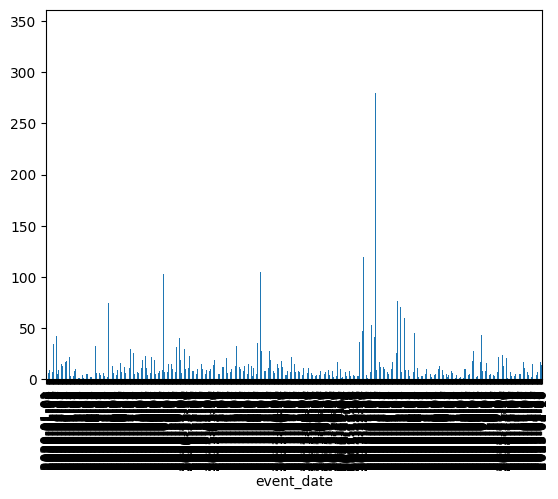

In [8]:
# plot number of events per day
df["event_date"] = pd.to_datetime(df["event_date"]).dt.date
# df = df[(df["event_date"] > "2022-01-01") & (df["event_date"] < "2022-02-01")]
df.groupby("event_date").size().plot.bar()

In [35]:
# extend jupyter pandas display
pd.set_option("display.max_rows", 500)
pd.set_option("display.max_columns", 50)

# show notes of events on 2022-01-10
for row in df[df["event_date"] == "2022-01-10"]["notes"].values[:10]:
    print(row)

On 10 January 2022, between 2,100 (according to the police) and 3,000 (organizers) people took to the streets in Halle (Westfalen) to protest against coronavirus-related measures. Counter-protesters gathered nearby and burned Christmas trees. [size=between 2,100 and 3,000]
On 10 January 2022, in the evening, more than 1,000 took to the streets in Lubeck, marching to the town hall and back to their starting point, to protest against coronavirus-related measures and demand vaccination freedom. A counter-protest of about 80 people was staged in the Falkenstrasse area. [size=more than 1,000]
On 10 January 2022, in the evening, hundreds of people took to the streets in the Brandenburger Strasse area of Potsdam, taking part in various 'walks', to protest against coronavirus-related measures. A counter-demonstration was staged in front of the Potsdam Parliament and Nauener Tor. [size=hundreds]
On 10 January 2022, about 1,000 people took to the streets in Regensburg to protest against coronavi

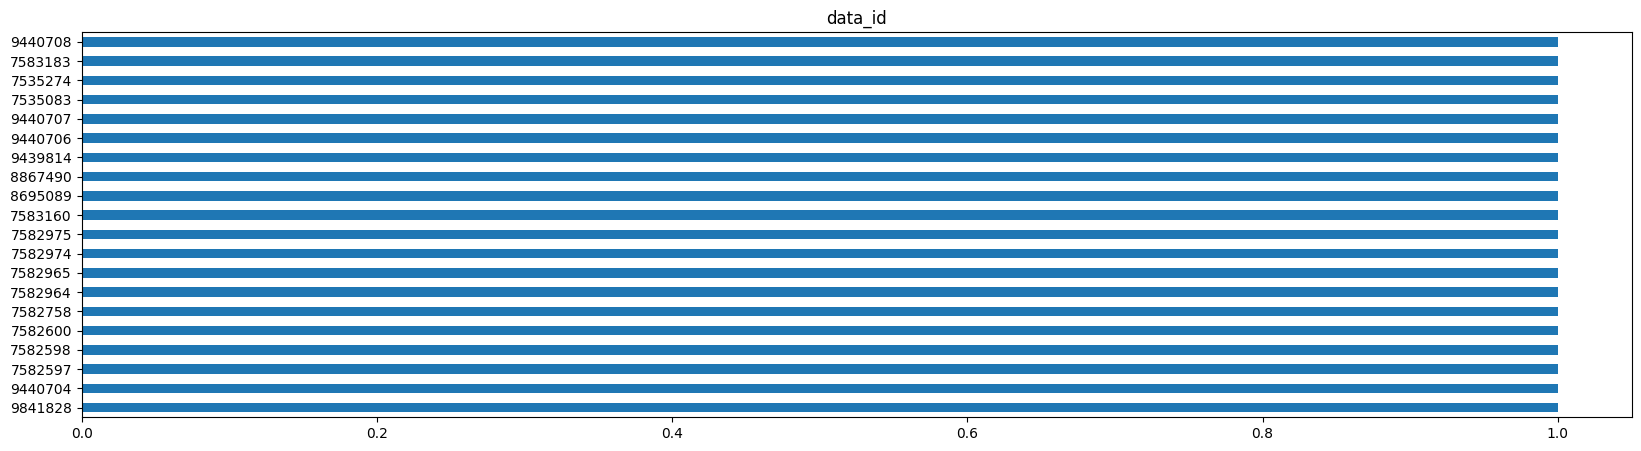

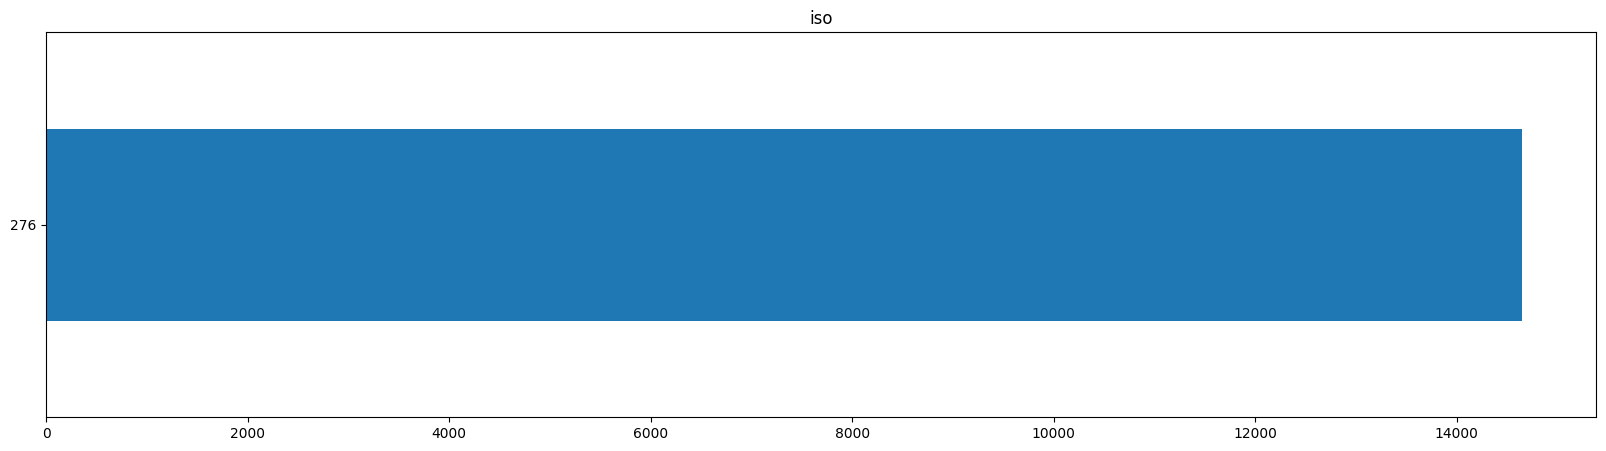

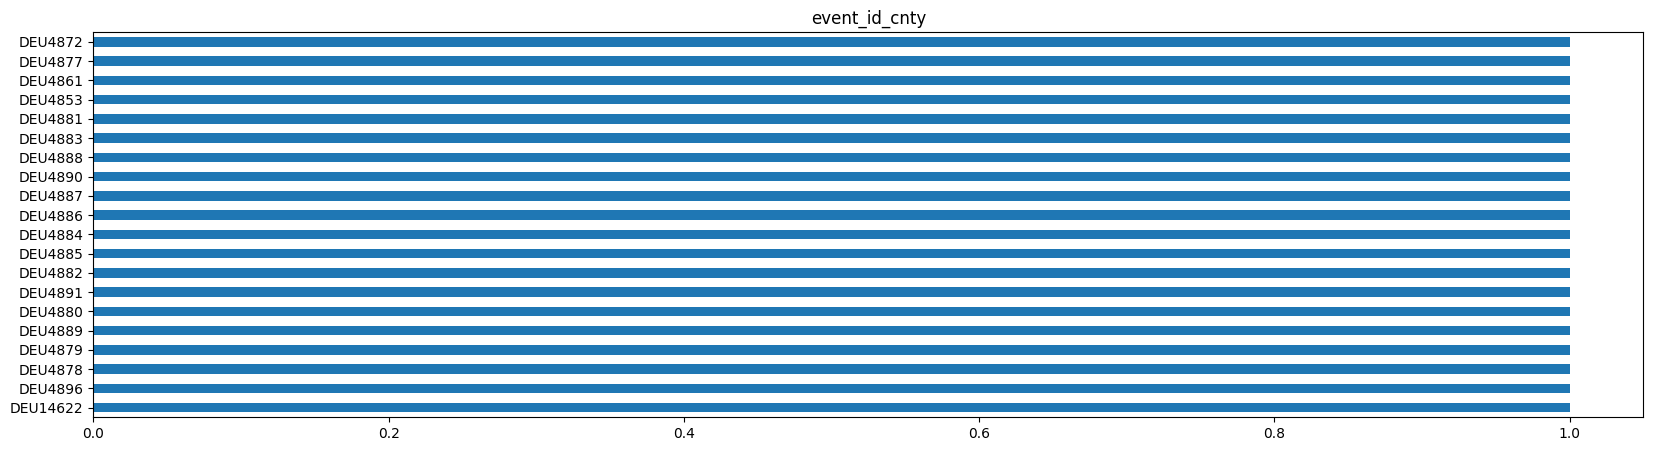

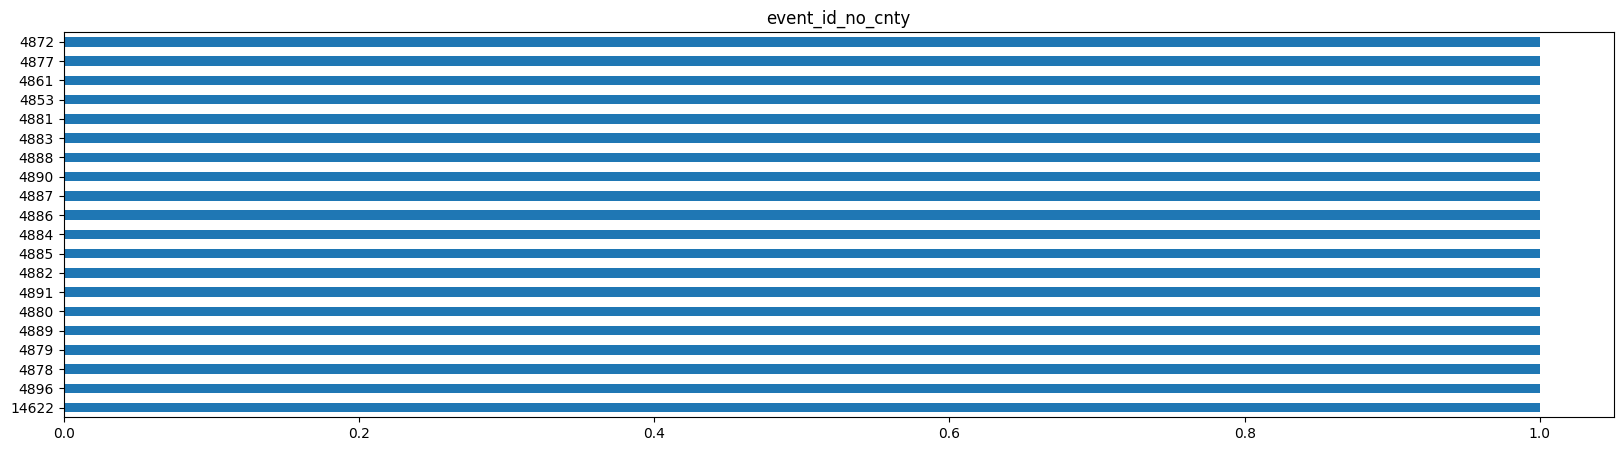

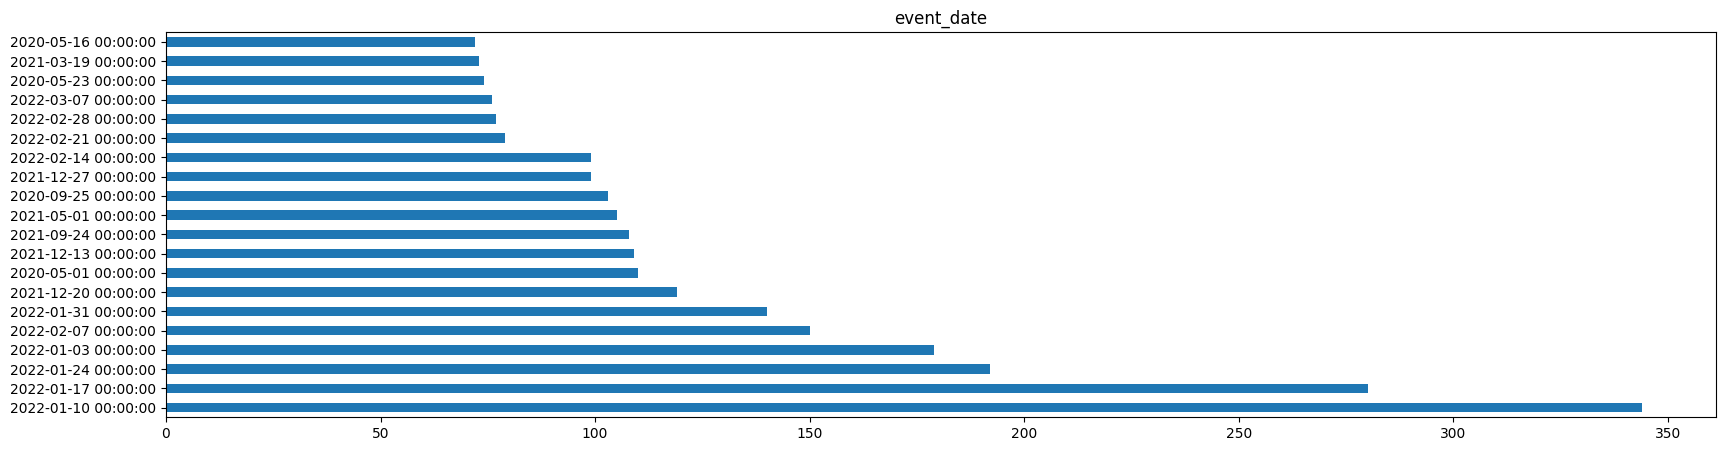

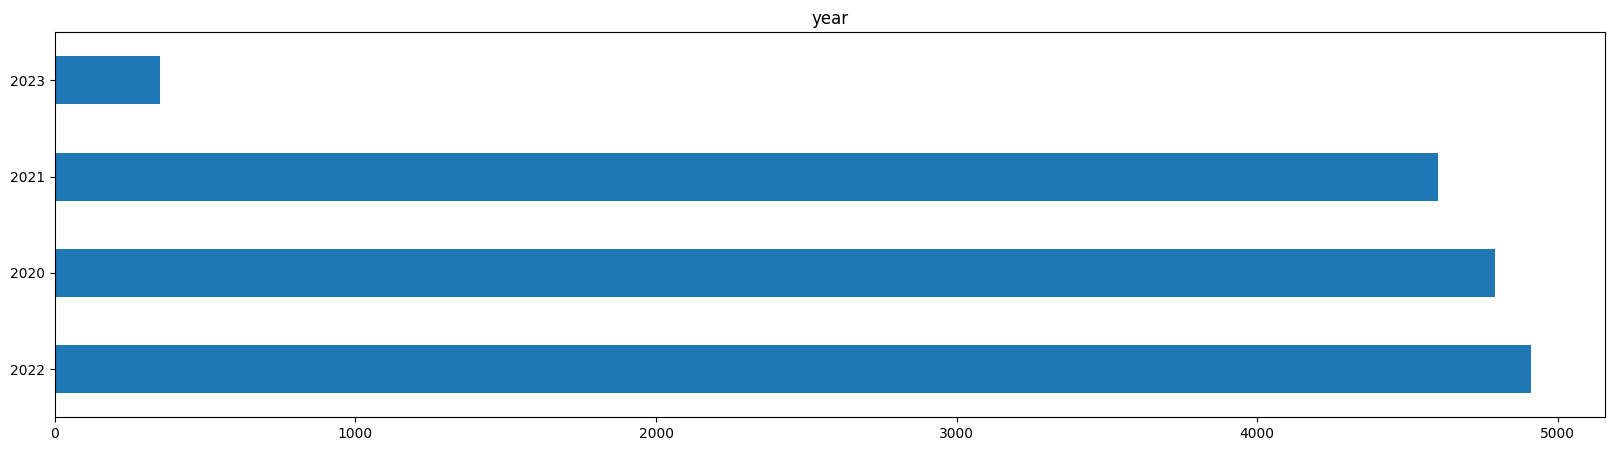

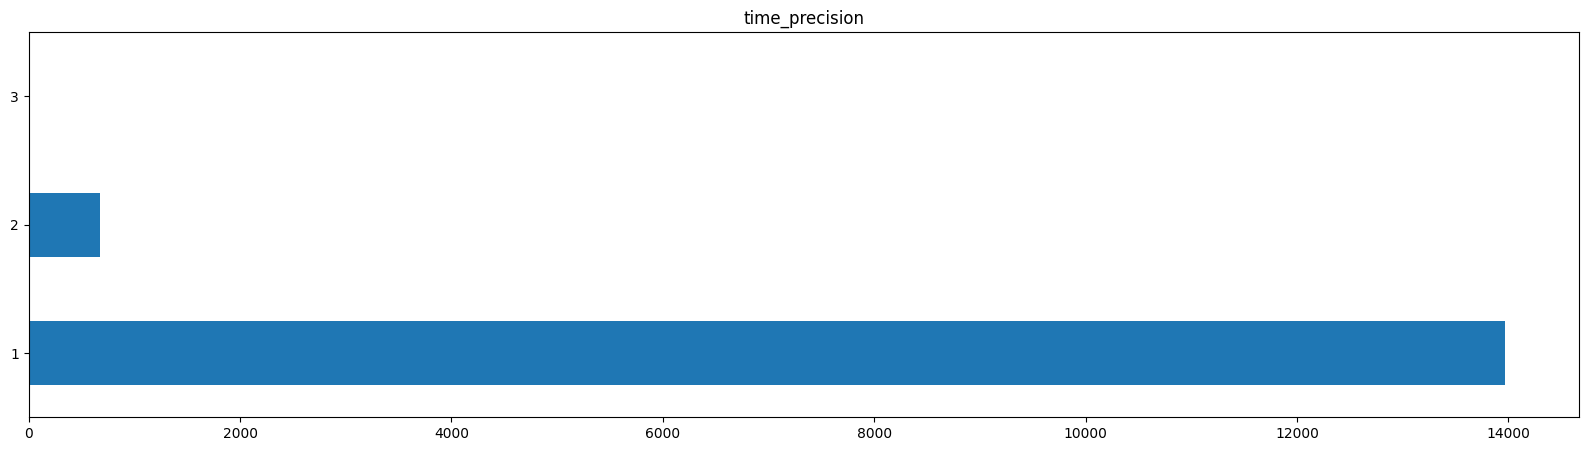

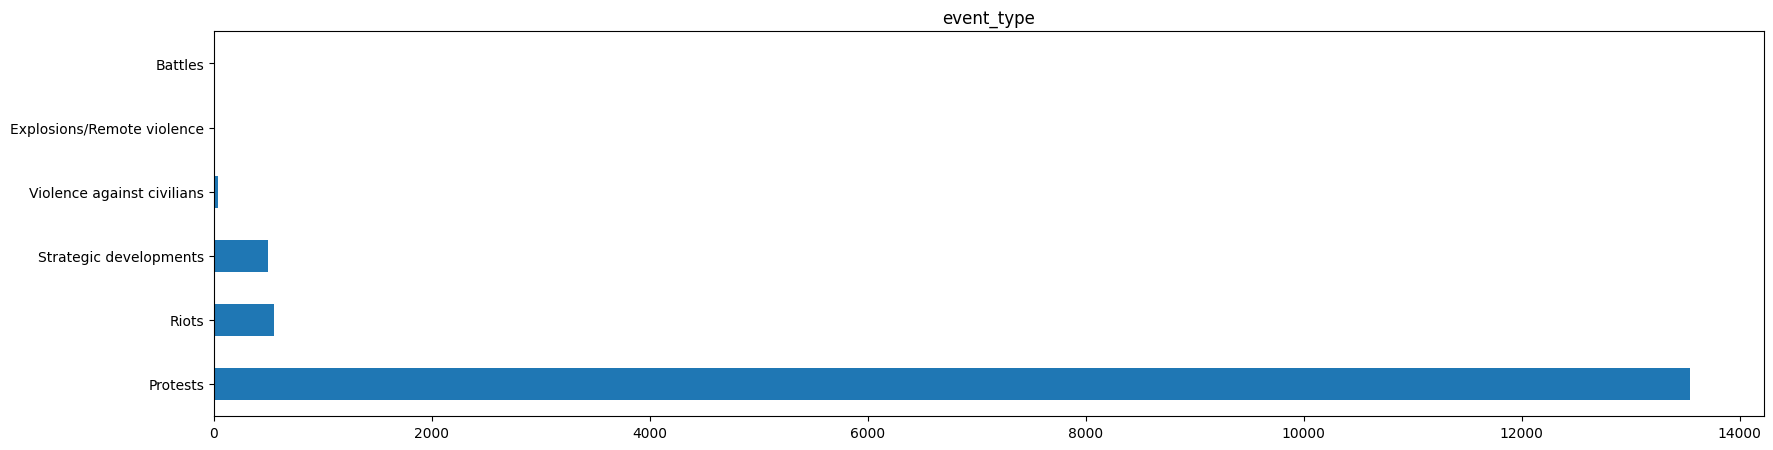

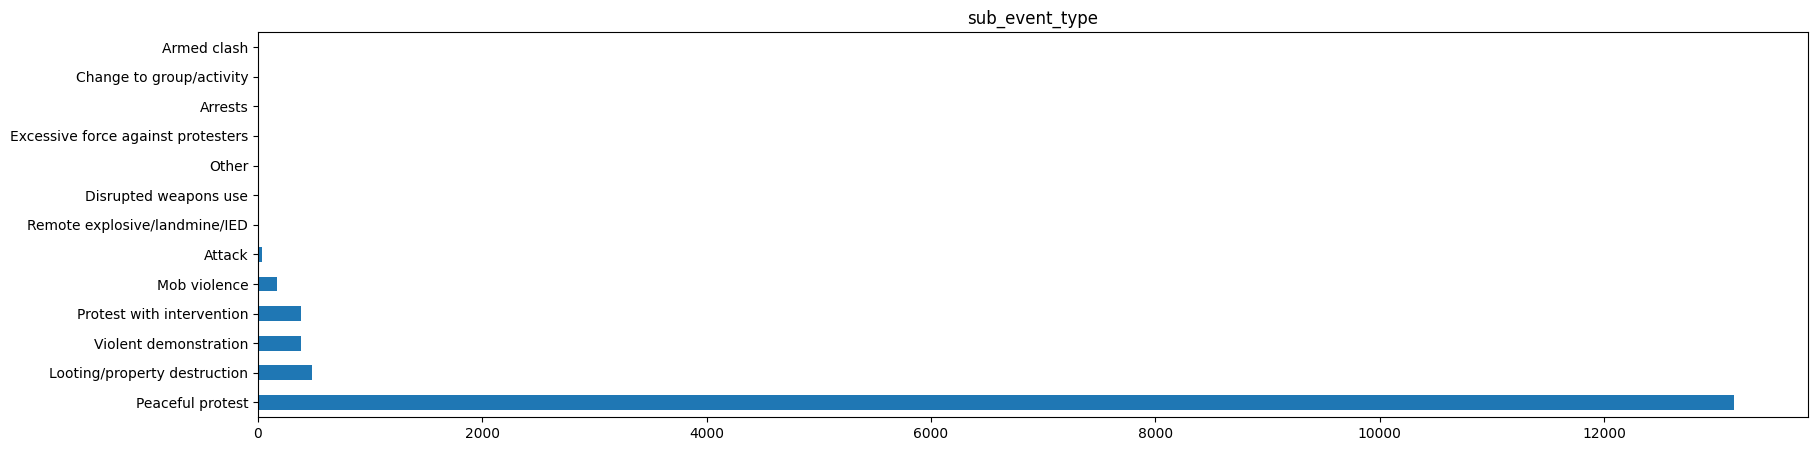

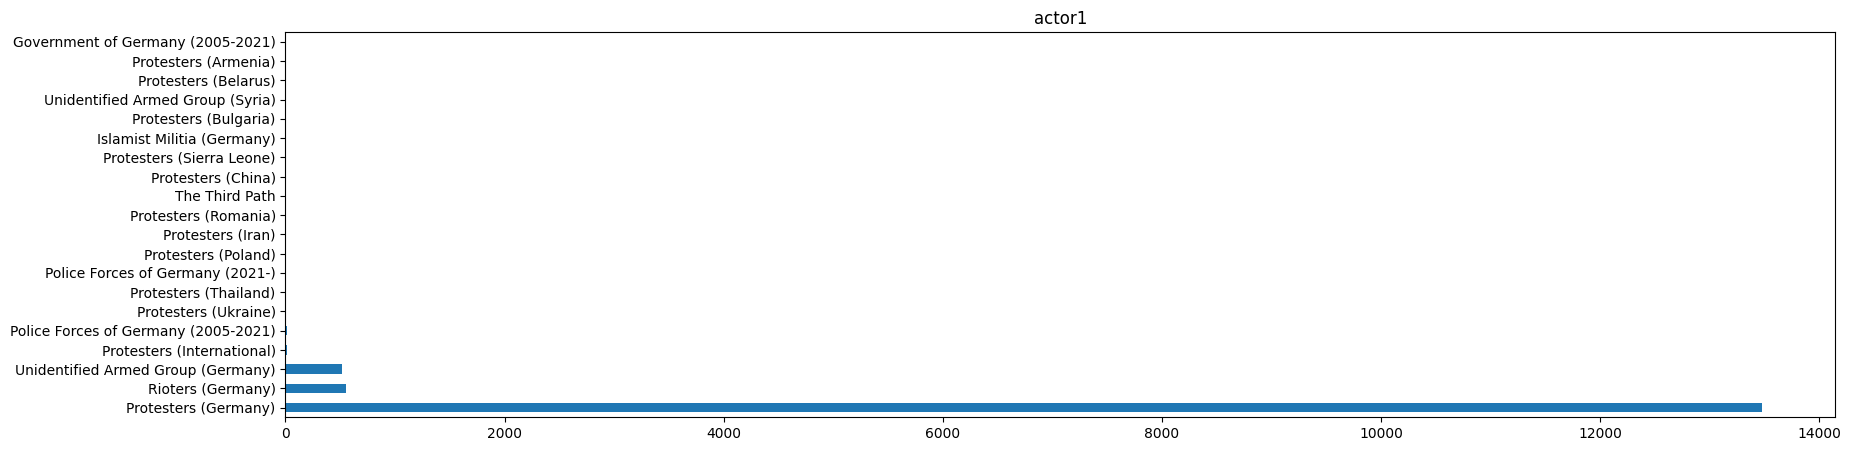

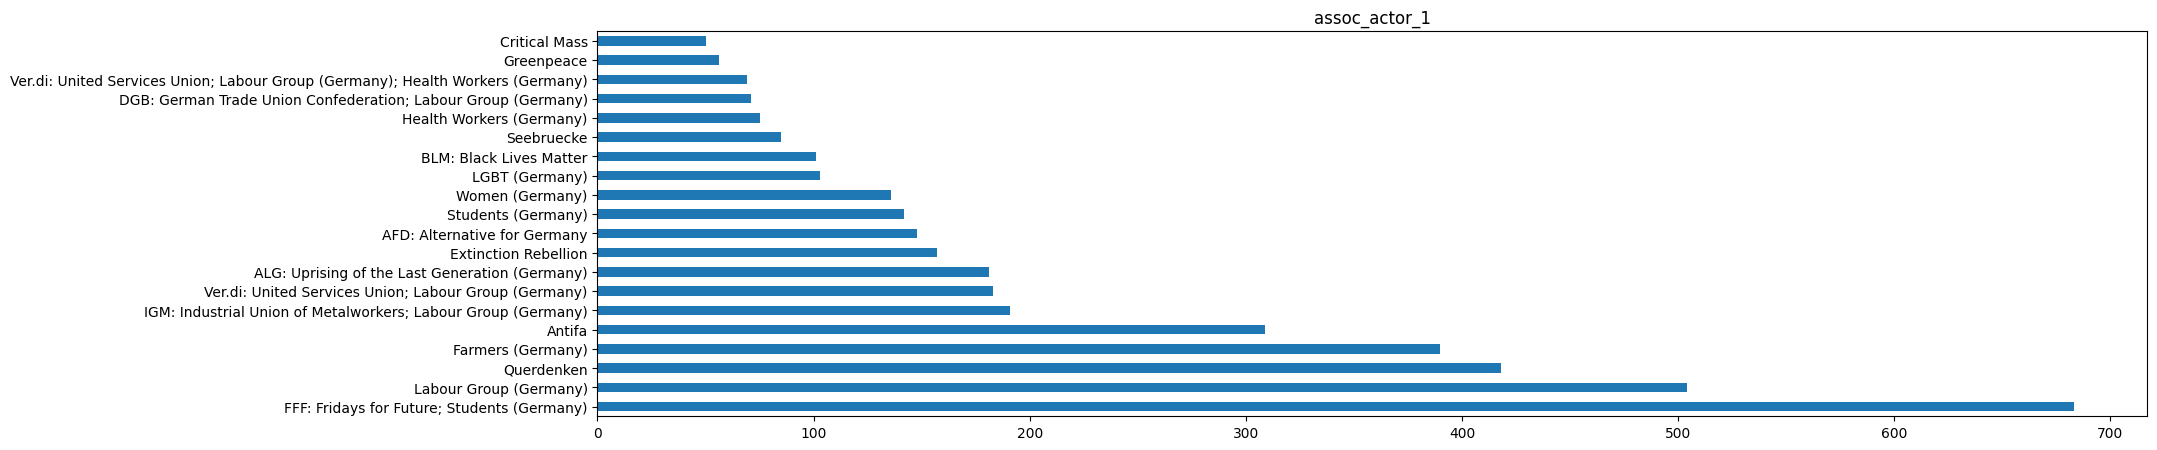

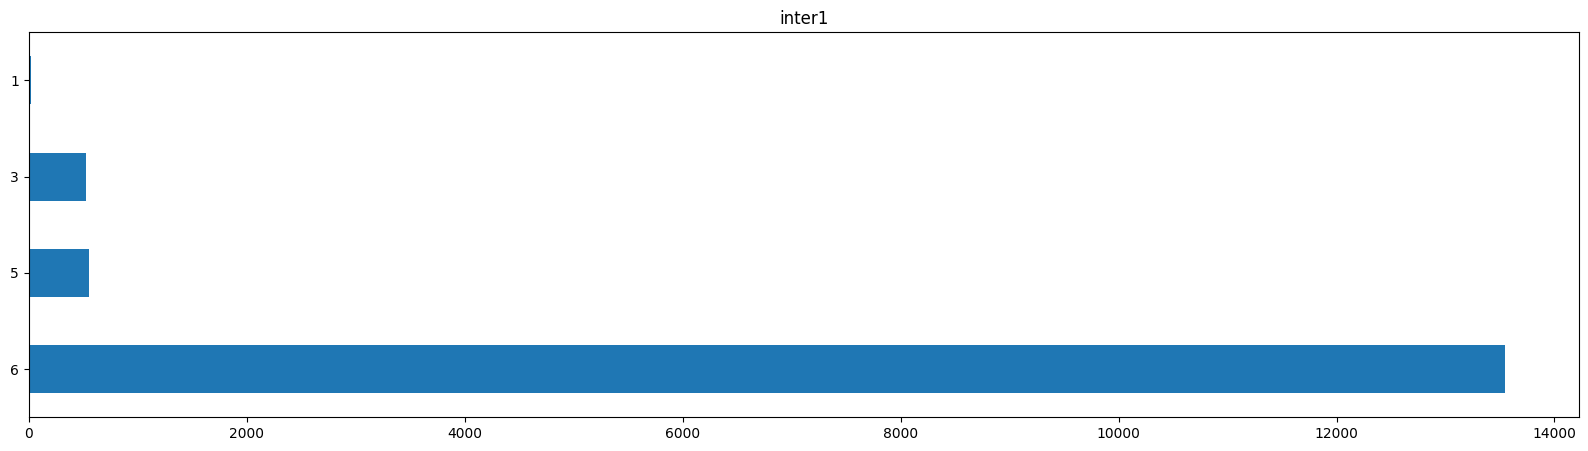

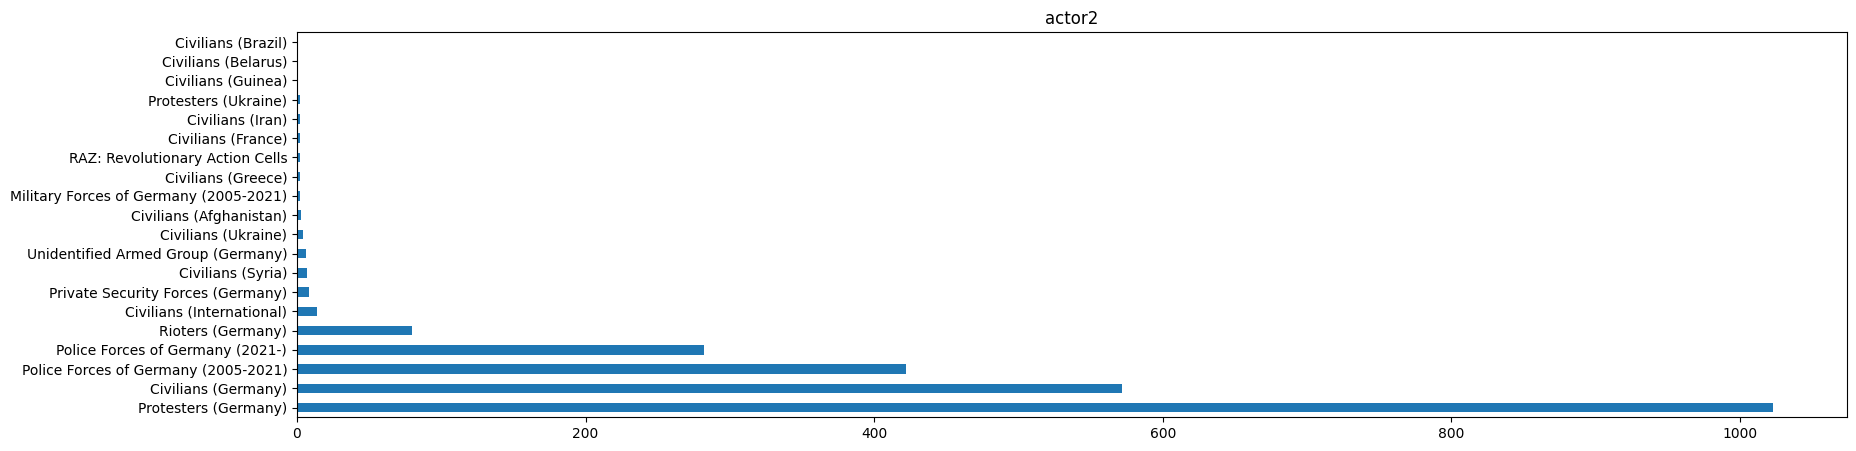

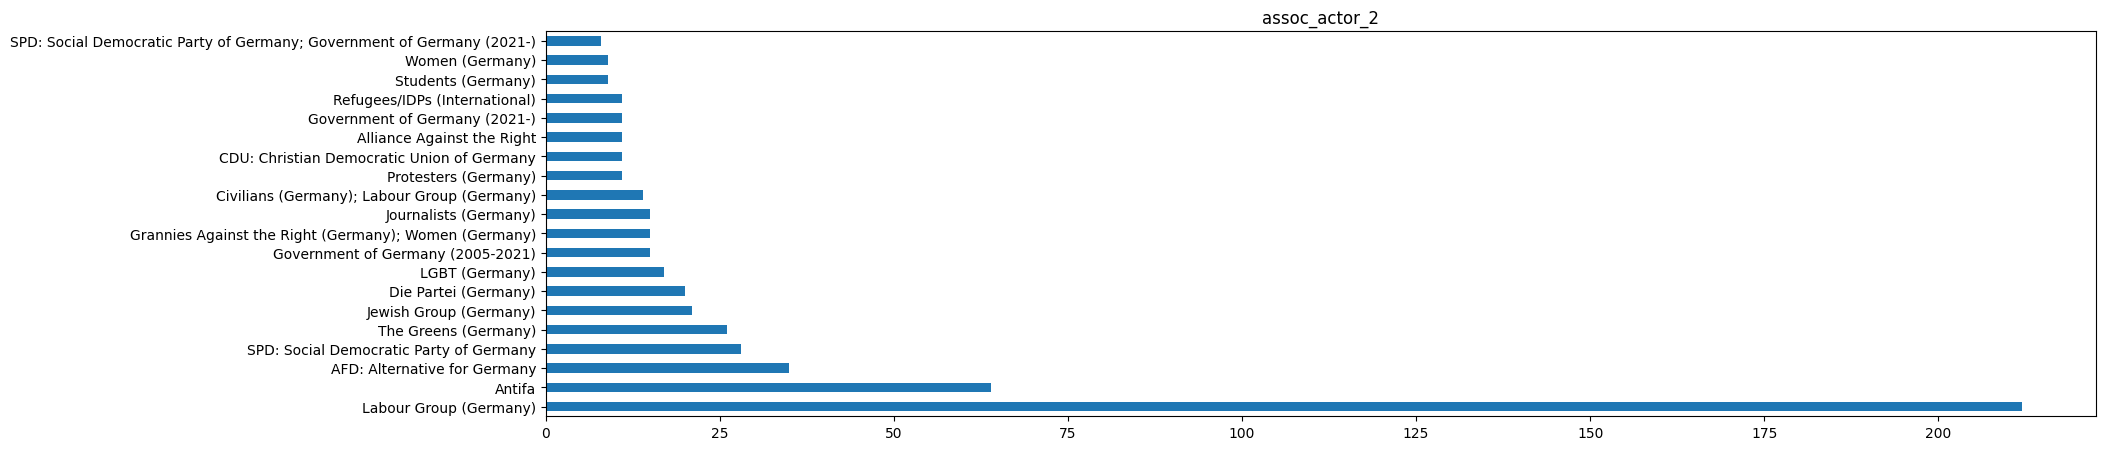

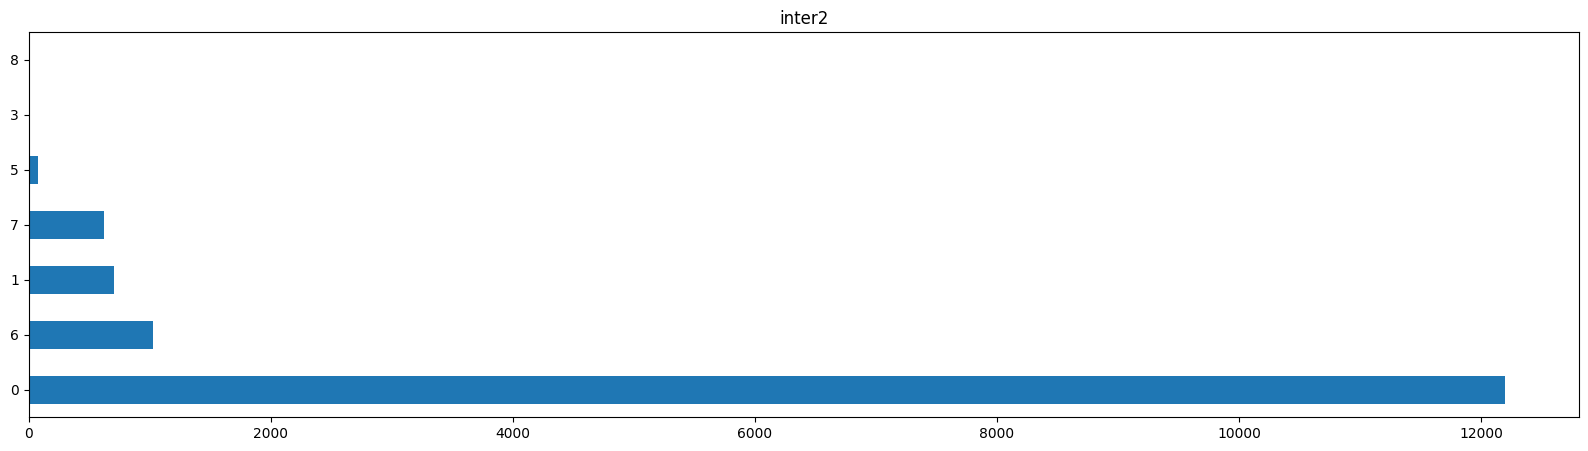

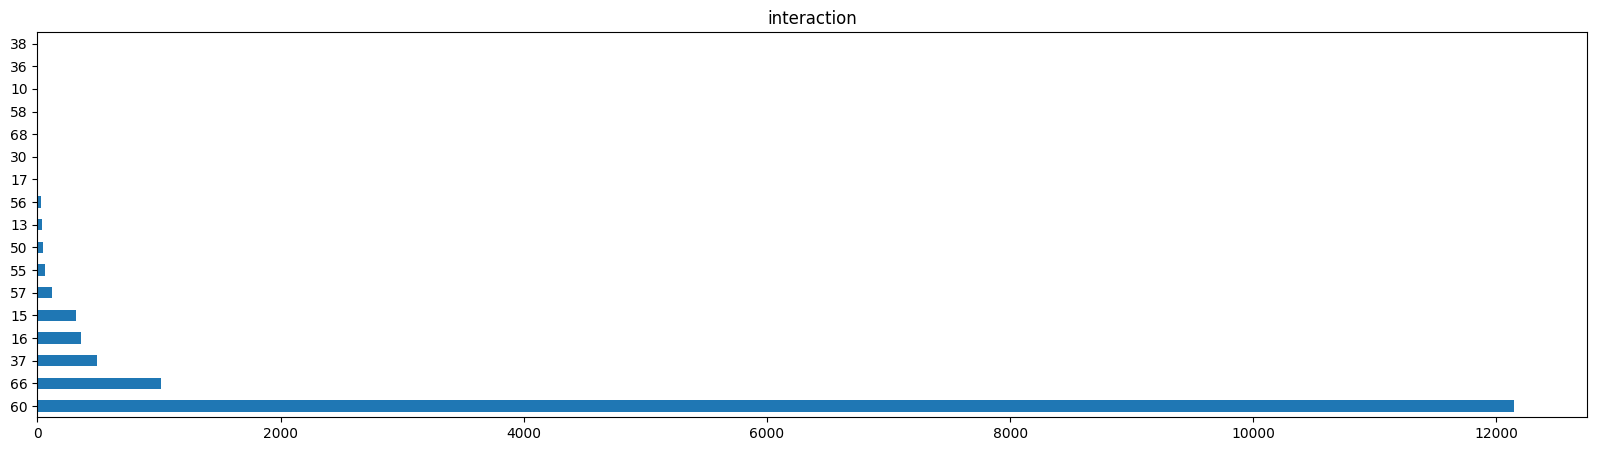

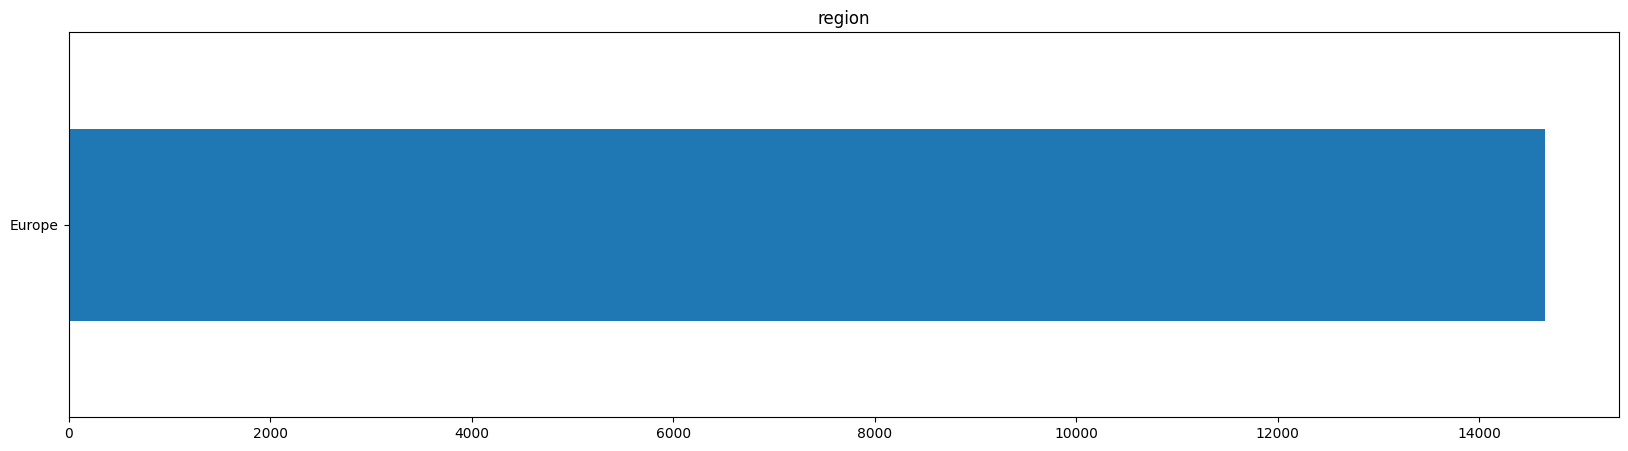

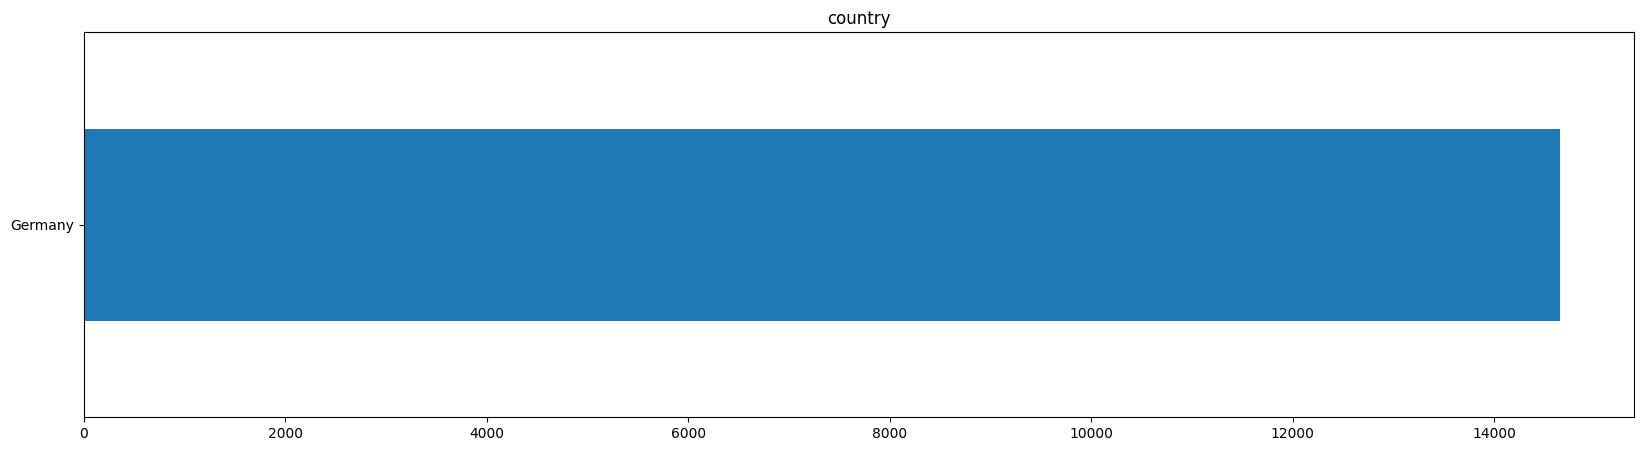

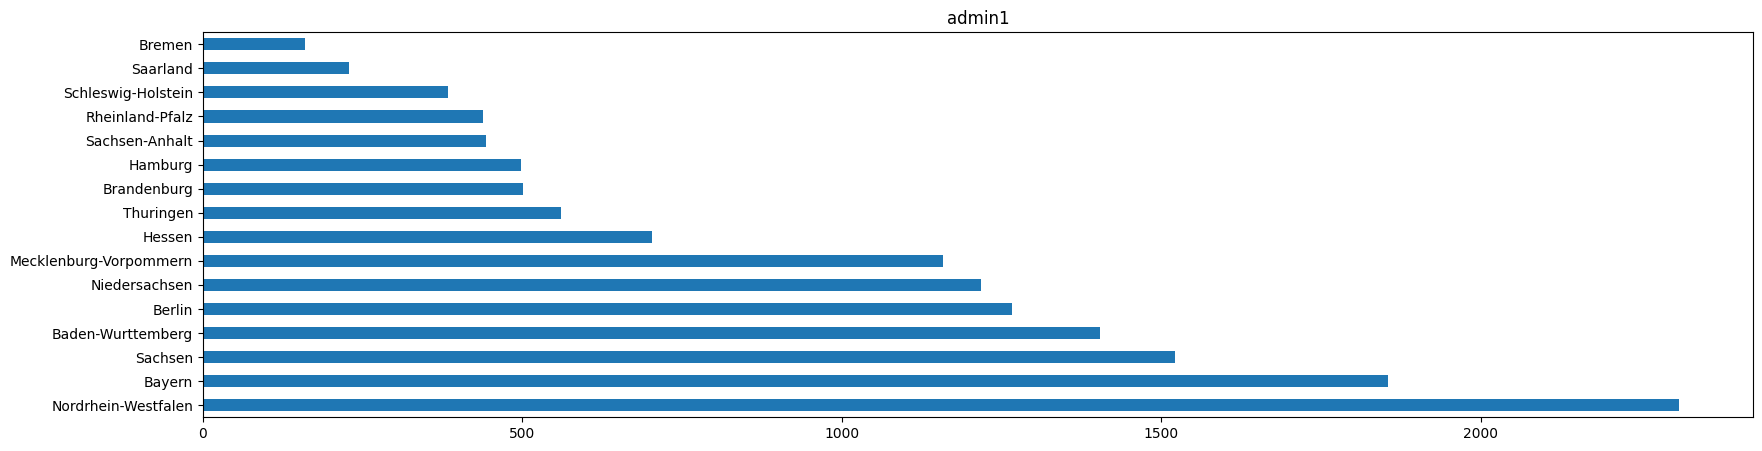

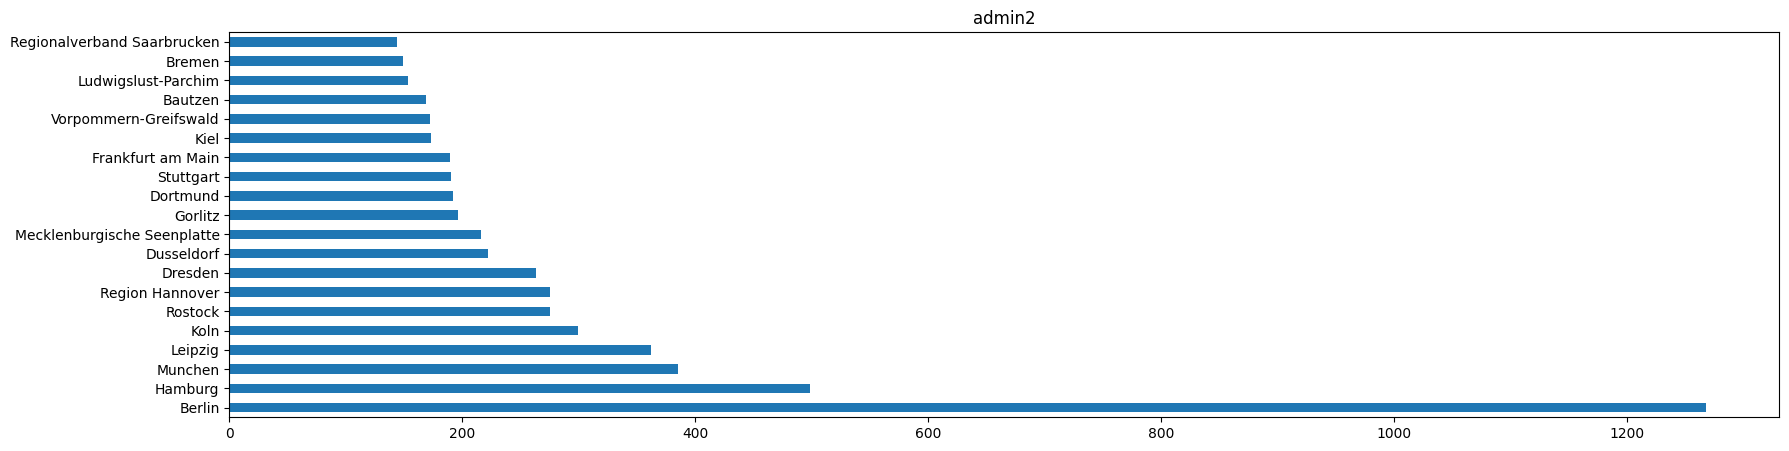

admin3 index 0 is out of bounds for axis 0 with size 0


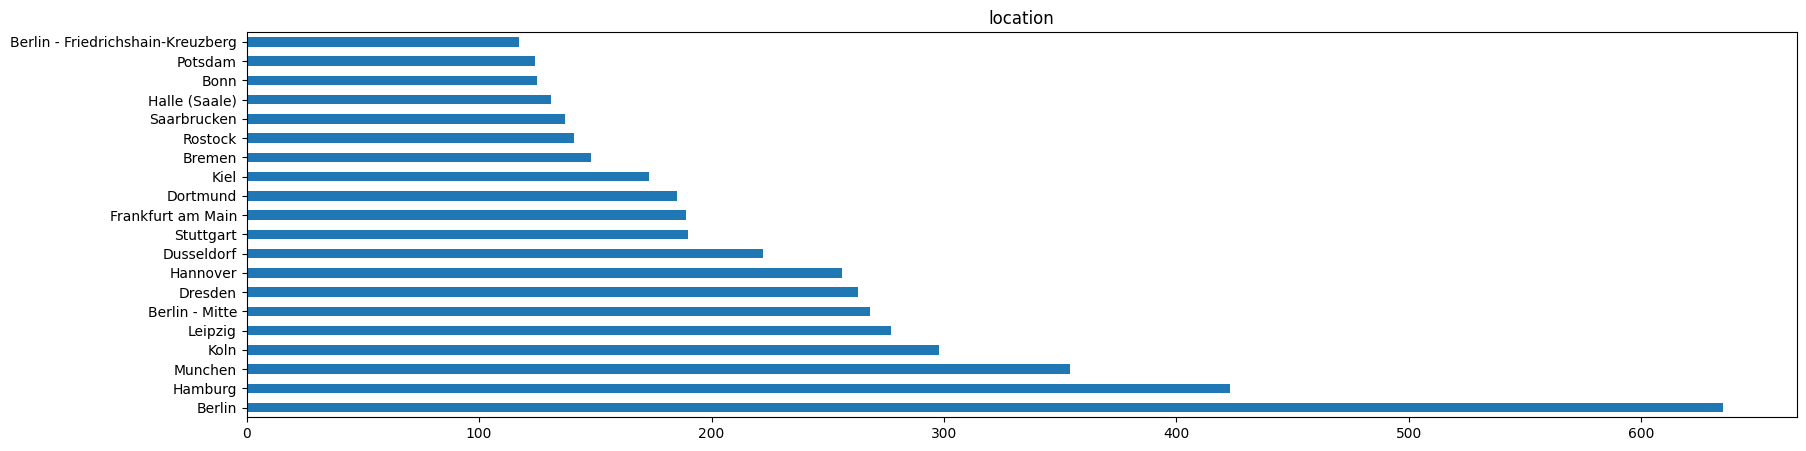

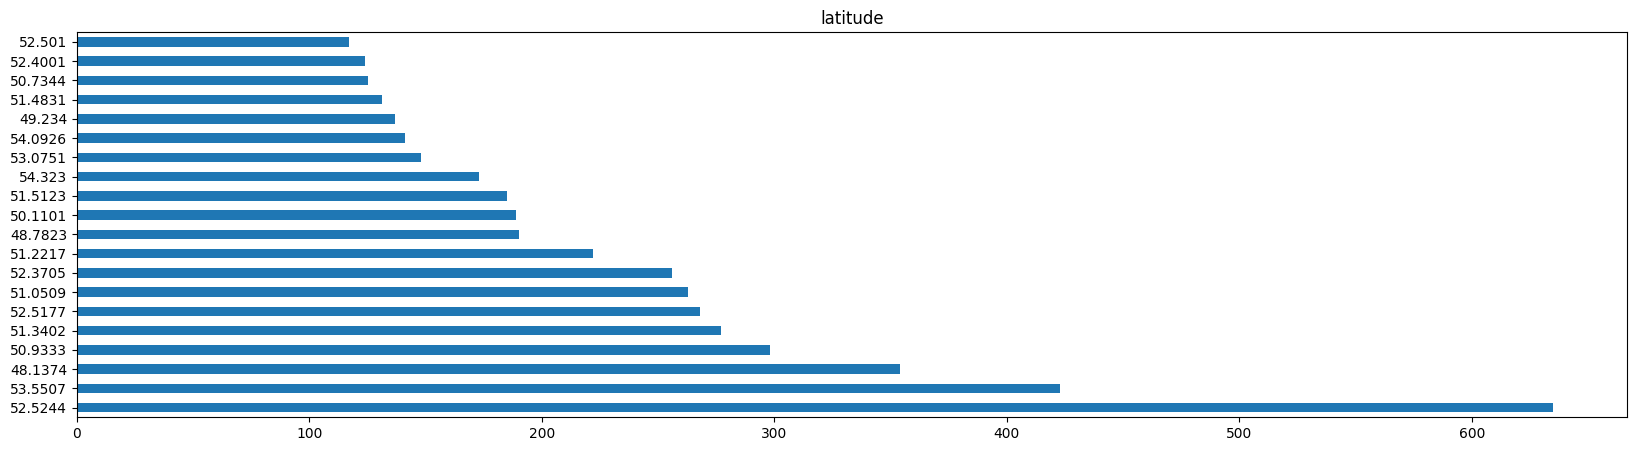

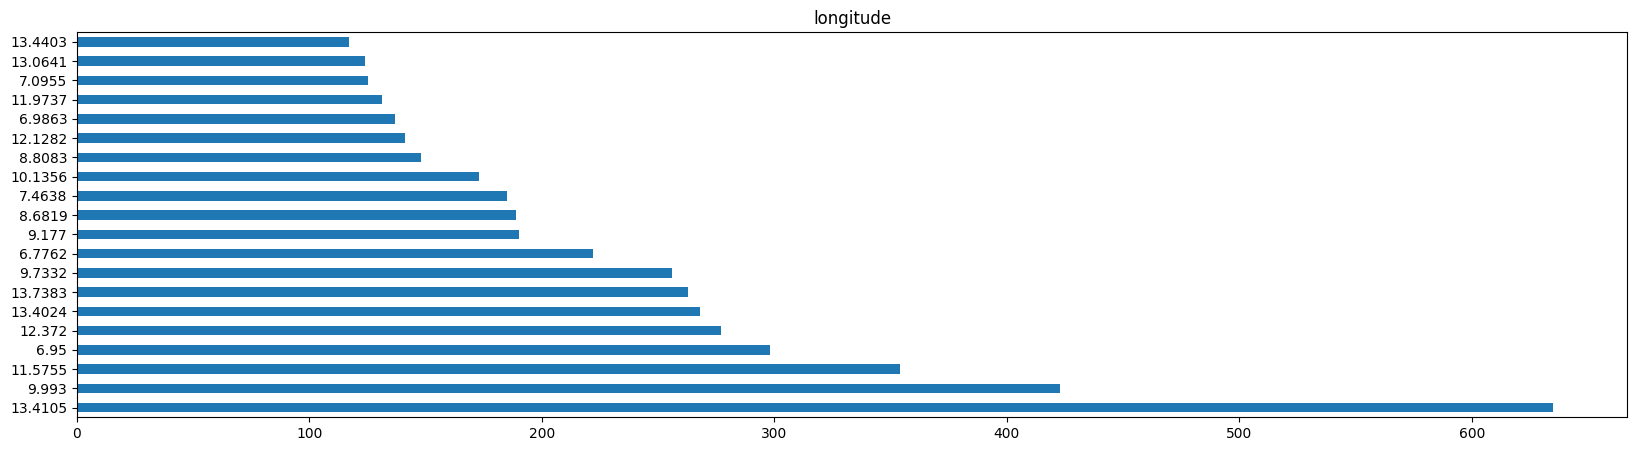

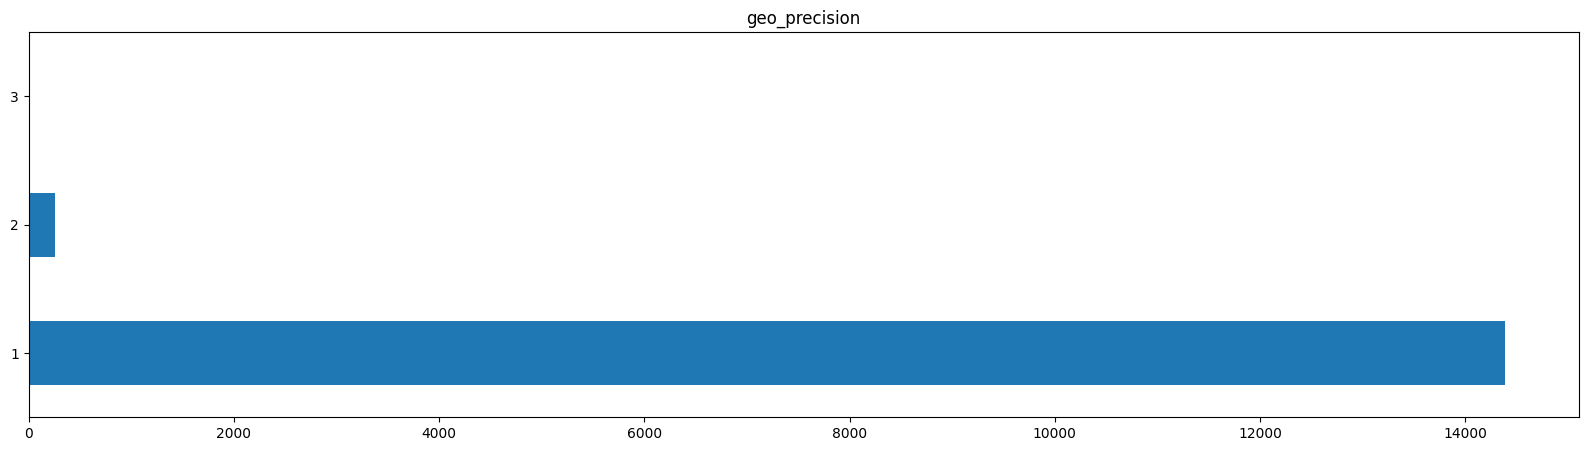

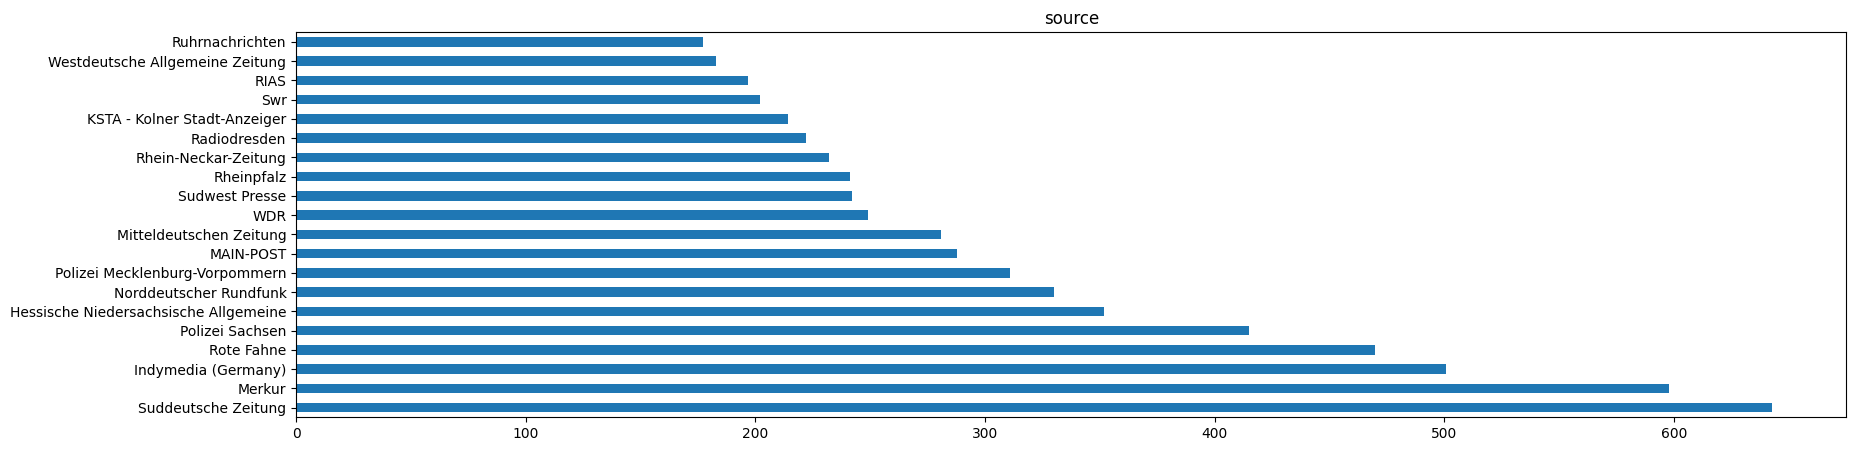

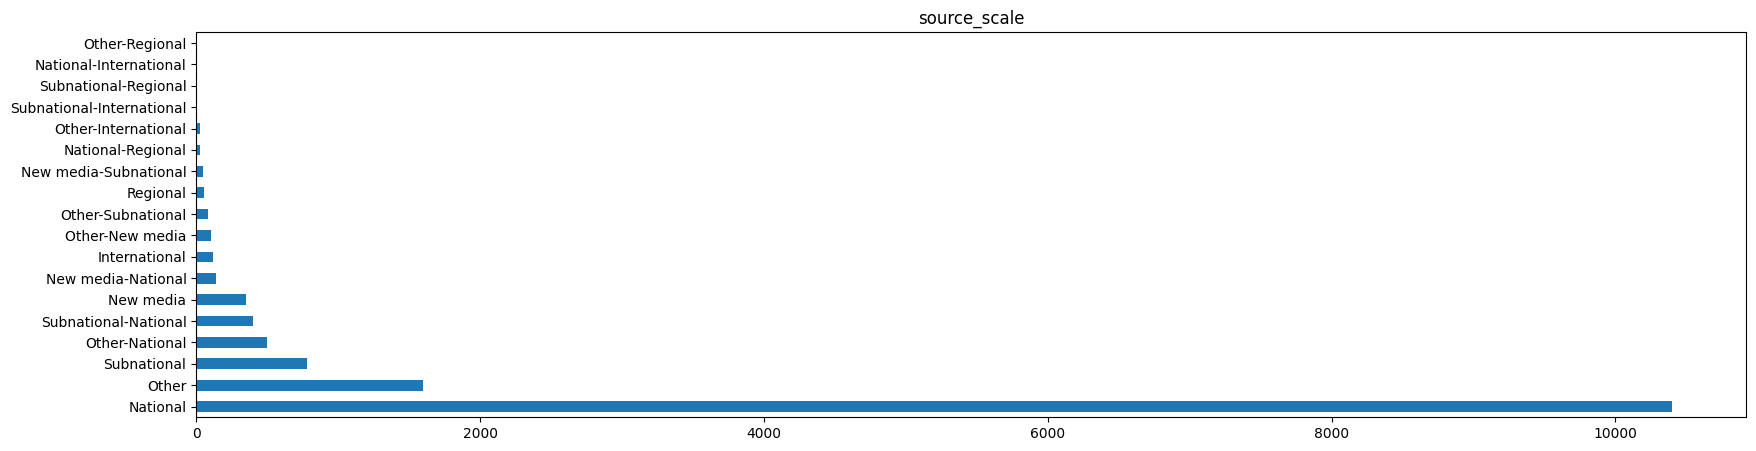

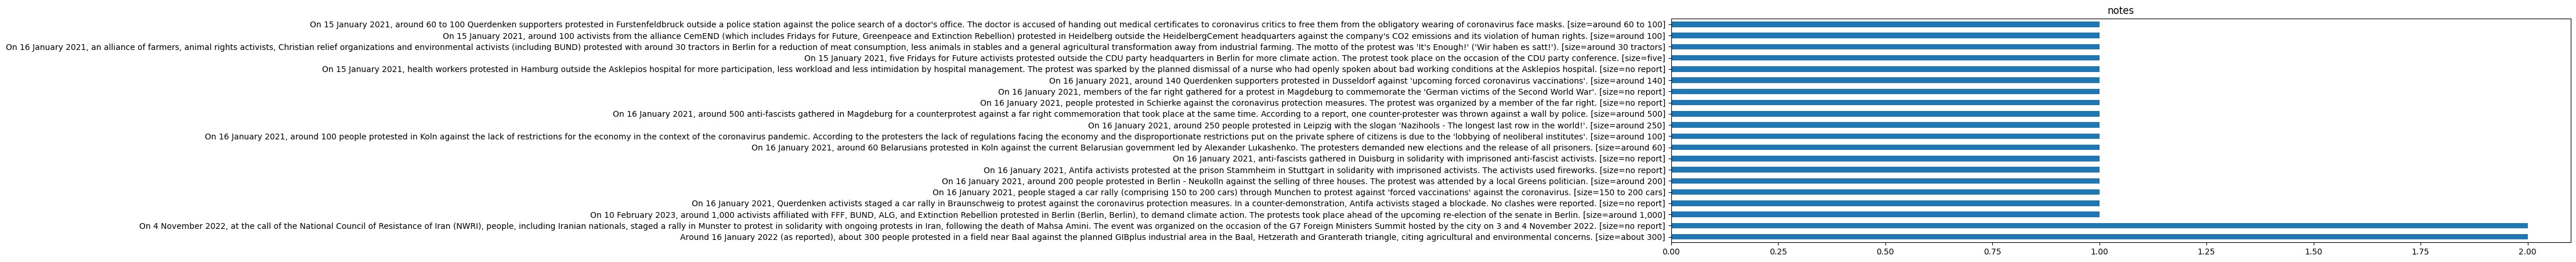

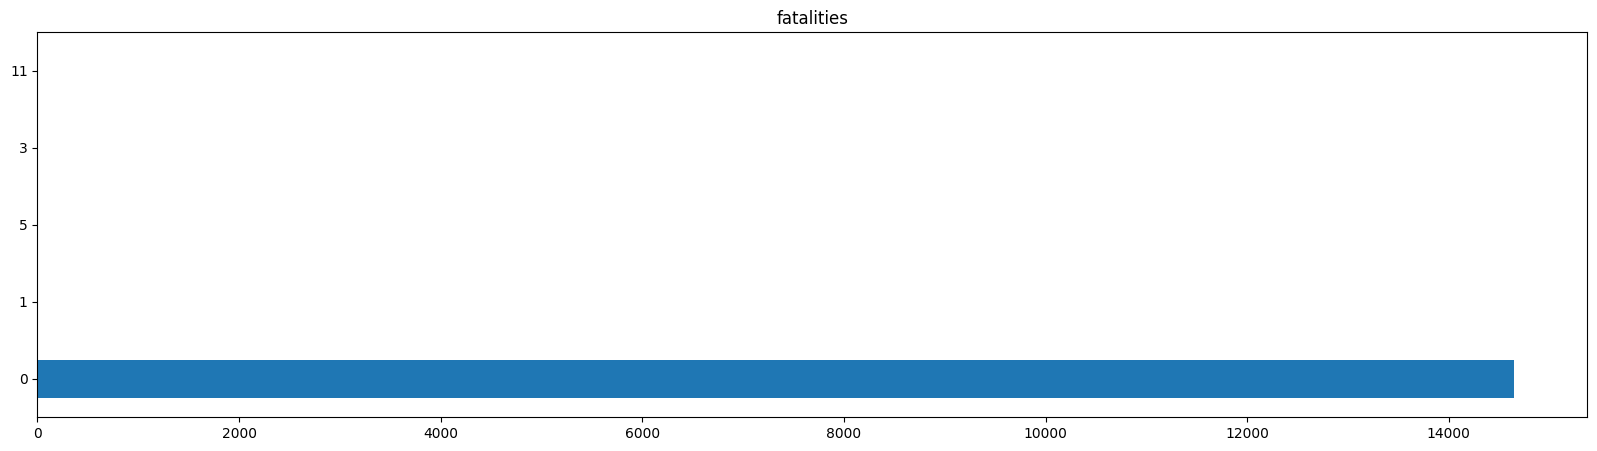

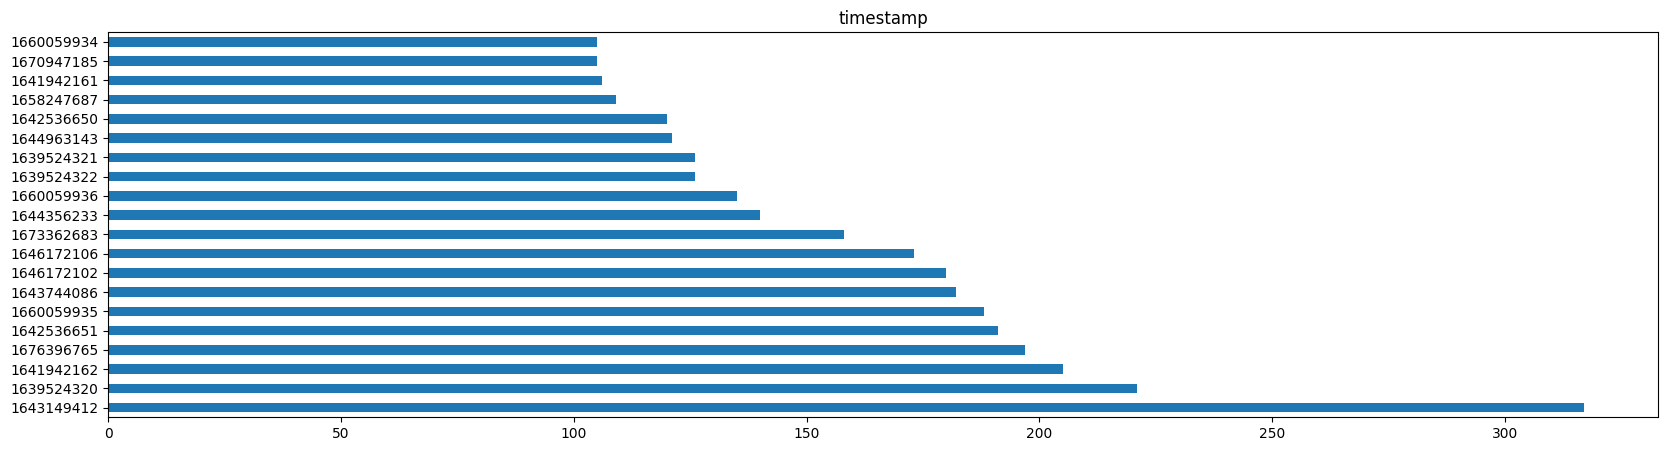

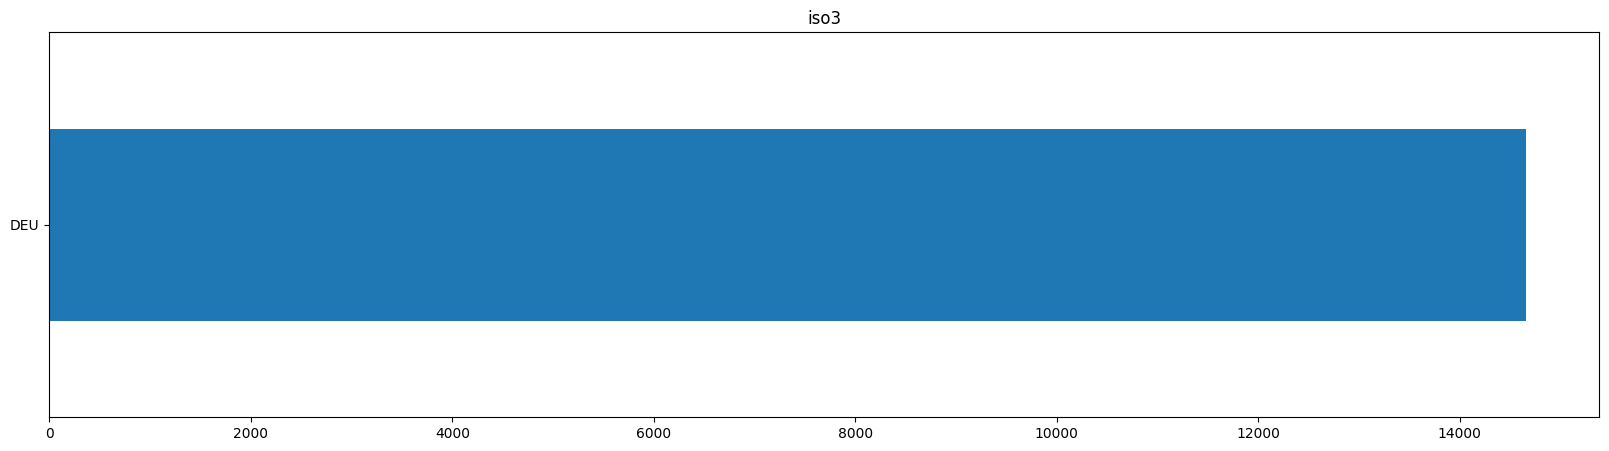

In [39]:
import matplotlib.pyplot as plt

# show bar plot of most frequent values for each column (with the legend on the y axis)
for col in df.columns:
    try:
        df[col].value_counts().head(20).plot.barh(figsize=(20, 5), title=col)
        plt.show()
    except Exception as e:
        print(col, e)